# True Signal SNR Calculation

Compute the true SNR of the injected signal using the optimal SNR formula:

$$\text{SNR} = \sqrt{4 \int_0^\infty \frac{|\tilde{h}(f)|^2}{S_n(f)} df} = \sqrt{4 \Delta f \sum_i \frac{|\tilde{h}(f_i)|^2}{S_n(f_i)}}$$

where $\tilde{h}(f)$ is the Fourier transform of the signal, $S_n(f)$ is the noise PSD, and $\Delta f = 1/T$ is the frequency resolution.

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from gwpy.timeseries import TimeSeries
from scipy import signal
import seaborn as sns

sns.set(style='whitegrid', context='paper', font_scale=1.5)

## Configuration

In [8]:
# Detector configuration (same as preprocessing)
DETECTORS = {
    'H1': {
        'channel_name': 'H1:GW-H',
        't0_gps': 1126259462.423,
        'F_plus': 0.578742411175002,
        'F_cross': -0.45094782109531206,
        'color': 'blue'
    },
    'L1': {
        'channel_name': 'L1:GW-L',
        't0_gps': 1126259462.4160156,
        'F_plus': -0.5274334329518102,
        'F_cross': 0.20520960891727422,
        'color': 'orange'
    }
}

# Experiment parameters
DURATIONS = [4.0, 8.0, 16.0, 32.0]  # seconds
AMPLIFY_FACTORS = [1.25, 0.62, 0.31]

# Processing parameters (same as preprocessing)
scale_factor = 1e-23
target_sample_rate = 4096  # Hz
tukey_alpha = 0.1

# Paths
data_dir = '/home/x-ctirapongpra/scratch/gw-collapsar/h(t)'
output_base_dir = '../Frames_1000'

print(f"Configuration loaded")
print(f"Detectors: {list(DETECTORS.keys())}")
print(f"Durations: {DURATIONS}")
print(f"Amplitude factors: {AMPLIFY_FACTORS}")

Configuration loaded
Detectors: ['H1', 'L1']
Durations: [4.0, 8.0, 16.0, 32.0]
Amplitude factors: [1.25, 0.62, 0.31]


## Load Raw Signal Data

In [9]:
# Load raw strain polarizations
time_data = np.loadtxt(os.path.join(data_dir, 't.txt'), delimiter=',')
hp_x = np.loadtxt(os.path.join(data_dir, 'hp_x.txt'))
hx_x = np.loadtxt(os.path.join(data_dir, 'hx_x.txt'))

# Calculate sample rate
dt = time_data[1] - time_data[0]
sample_rate = 1.0 / dt

print(f"Raw data loaded:")
print(f"  Sample rate: {sample_rate:.2f} Hz")
print(f"  Duration: {time_data[-1] - time_data[0]:.3f} s")
print(f"  Samples: {len(time_data)}")

Raw data loaded:
  Sample rate: 10000.00 Hz
  Duration: 24.000 s
  Samples: 240000


## Generate Noise-Only PSD

Generate Gaussian noise colored by aLIGO design sensitivity curve, then compute PSD from this noise-only data. This PSD will be used for all SNR calculations.

In [10]:
def aLIGO_psd(f):
    """
    Analytical approximation of aLIGO design sensitivity.
    Based on LIGO-T1800044 document.
    
    Returns PSD in strain^2/Hz
    """
    # Avoid division by zero
    f = np.asarray(f)
    f = np.where(f > 0, f, 1e-10)
    
    # aLIGO design sensitivity parameters (simplified model)
    # Reference: https://dcc.ligo.org/LIGO-T1800044/public
    f0 = 215.0  # Hz - reference frequency
    S0 = 1.0e-49  # strain^2/Hz at reference
    
    # Low frequency (seismic) wall
    x = f / f0
    
    # Simplified aLIGO noise curve
    # Combines seismic, thermal, and quantum noise
    psd = S0 * (
        (4.49 * x)**(-56) +    # seismic wall
        0.16 * x**(-4.52) +     # suspension thermal
        0.52 +                   # coating thermal  
        0.32 * x**2              # quantum noise
    )
    
    return psd


def generate_colored_noise(duration, sample_rate, psd_func, seed=None):
    """
    Generate Gaussian noise colored by a given PSD.
    
    Parameters
    ----------
    duration : float
        Duration in seconds
    sample_rate : float
        Sample rate in Hz
    psd_func : callable
        Function that returns PSD values for given frequencies
    seed : int, optional
        Random seed for reproducibility
    
    Returns
    -------
    noise : np.ndarray
        Colored noise time series
    """
    if seed is not None:
        np.random.seed(seed)
    
    n_samples = int(duration * sample_rate)
    delta_t = 1.0 / sample_rate
    delta_f = 1.0 / duration
    
    # Generate white noise in frequency domain
    # For real-valued time series, we need n_samples//2 + 1 complex values
    n_freqs = n_samples // 2 + 1
    freqs = np.fft.rfftfreq(n_samples, d=delta_t)
    
    # Get target PSD (amplitude spectral density squared)
    target_psd = psd_func(freqs)
    
    # Generate complex Gaussian noise
    # Real and imaginary parts are independent N(0, 1)
    white_noise_fft = (np.random.randn(n_freqs) + 1j * np.random.randn(n_freqs)) / np.sqrt(2)
    
    # Color the noise: multiply by sqrt(PSD) and scale properly
    # The factor ensures correct variance in time domain
    amplitude = np.sqrt(target_psd * sample_rate / 2)
    colored_noise_fft = white_noise_fft * amplitude
    
    # DC and Nyquist components should be real
    colored_noise_fft[0] = np.real(colored_noise_fft[0]) * np.sqrt(2)
    if n_samples % 2 == 0:
        colored_noise_fft[-1] = np.real(colored_noise_fft[-1]) * np.sqrt(2)
    
    # Transform back to time domain
    noise = np.fft.irfft(colored_noise_fft, n=n_samples)
    
    return noise


# Generate noise and compute PSD for each duration
noise_psd_dict = {}
psd_fftlength = 4
psd_overlap = 2

print("Generating noise-only PSD for each duration...")
print("Using aLIGO design sensitivity curve\n")

for target_duration in DURATIONS:
    # Generate longer noise segment for better PSD estimation
    # Use at least 4x the target duration for averaging
    noise_duration = max(target_duration * 4, 32.0)
    
    # Generate colored noise
    noise = generate_colored_noise(
        duration=noise_duration,
        sample_rate=target_sample_rate,
        psd_func=aLIGO_psd,
        seed=42  # Fixed seed for reproducibility
    )
    
    # Create TimeSeries
    ts_noise = TimeSeries(noise, sample_rate=target_sample_rate)
    
    # Compute PSD using same parameters as preprocessing
    psd = ts_noise.psd(fftlength=psd_fftlength, overlap=psd_overlap, method='median')
    
    # Store for later use
    config_key = f"dur_{int(target_duration):02d}s"
    noise_psd_dict[config_key] = {
        'freqs': psd.frequencies.value,
        'values': psd.value
    }
    
    print(f"Duration {int(target_duration):2d}s: Generated {noise_duration:.0f}s of noise, PSD has {len(psd)} frequency bins")

print("\nNoise PSD generation complete!")

Generating noise-only PSD for each duration...
Using aLIGO design sensitivity curve



/tmp/ipykernel_4177653/41123812.py:23: RuntimeWarning: overflow encountered in power
  (4.49 * x)**(-56) +    # seismic wall
/home/x-ctirapongpra/.local/lib/python3.9/site-packages/scipy/signal/_signaltools.py:3530: RuntimeWarning: invalid value encountered in subtract
  ret = data - np.mean(data, axis, keepdims=True)


Duration  4s: Generated 32s of noise, PSD has 8193 frequency bins
Duration  8s: Generated 32s of noise, PSD has 8193 frequency bins
Duration 16s: Generated 64s of noise, PSD has 8193 frequency bins
Duration 32s: Generated 128s of noise, PSD has 8193 frequency bins

Noise PSD generation complete!


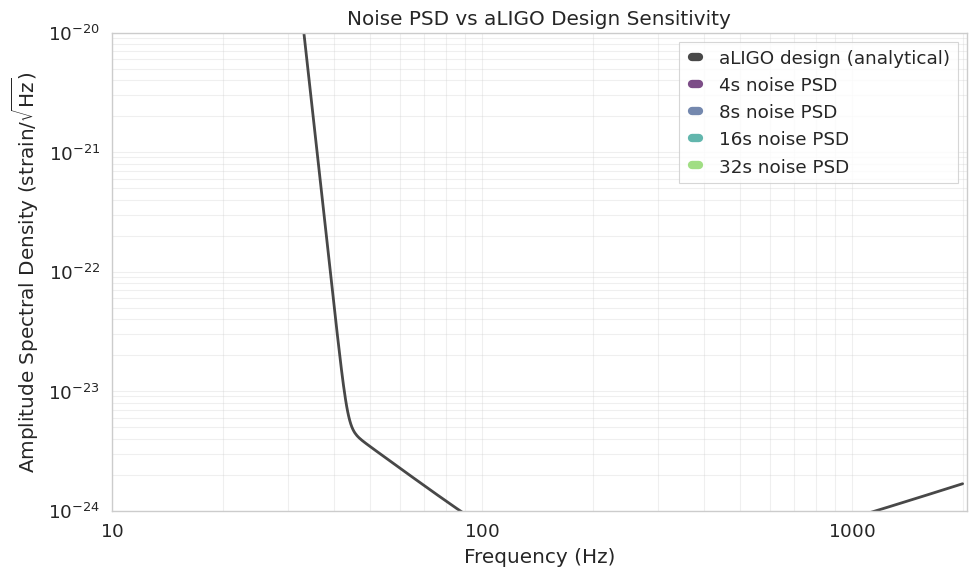

Noise PSD matches aLIGO design curve as expected.


In [11]:
# Visualize noise PSD compared to aLIGO design curve
fig, ax = plt.subplots(figsize=(10, 6))

# Plot theoretical aLIGO curve
f_theory = np.logspace(0.5, 3.3, 1000)  # 3 Hz to 2000 Hz
psd_theory = aLIGO_psd(f_theory)
ax.loglog(f_theory, np.sqrt(psd_theory), 'k-', linewidth=2, label='aLIGO design (analytical)', alpha=0.8)

# Plot computed noise PSDs for each duration
colors = plt.cm.viridis(np.linspace(0, 0.8, len(DURATIONS)))
for i, dur in enumerate(DURATIONS):
    config_key = f"dur_{int(dur):02d}s"
    psd_data = noise_psd_dict[config_key]
    mask = psd_data['freqs'] > 5  # Only plot above 5 Hz
    ax.loglog(psd_data['freqs'][mask], np.sqrt(psd_data['values'][mask]), 
              color=colors[i], linewidth=1, alpha=0.7, label=f'{int(dur)}s noise PSD')

ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Amplitude Spectral Density (strain/$\\sqrt{\\mathrm{Hz}}$)')
ax.set_title('Noise PSD vs aLIGO Design Sensitivity')
ax.set_xlim(10, 2048)
ax.set_ylim(1e-24, 1e-20)
ax.legend()
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

print("Noise PSD matches aLIGO design curve as expected.")

In [12]:
def compute_signal_snr(signal_timeseries, psd_freqs, psd_values):
    """
    Compute the optimal matched-filter SNR of a signal.
    
    SNR = sqrt( 4 * Delta_f * Sum_i |d(f_i)|^2 / S(f_i) )
    
    Parameters
    ----------
    signal_timeseries : TimeSeries
        Time-domain signal data
    psd_freqs : np.ndarray
        PSD frequency array
    psd_values : np.ndarray
        PSD values at each frequency
    
    Returns
    -------
    float
        Optimal SNR
    """
    # Get signal data and parameters
    signal_data = signal_timeseries.value
    sample_rate = signal_timeseries.sample_rate.value
    duration = signal_timeseries.duration.value
    
    # Frequency resolution
    delta_f = 1.0 / duration
    delta_t = 1.0 / sample_rate
    
    # Compute FFT of signal (with proper units: multiply by delta_t)
    signal_fft = np.fft.rfft(signal_data) * delta_t
    signal_freqs = np.fft.rfftfreq(len(signal_data), d=delta_t)
    
    # Interpolate PSD to match signal frequency bins
    psd_interp = np.interp(signal_freqs, psd_freqs, psd_values, 
                           left=psd_values[0], right=psd_values[-1])
    
    # Avoid division by zero
    psd_interp = np.where(psd_interp > 0, psd_interp, np.inf)
    
    # Compute SNR^2
    # The factor of 4 comes from: 4 * integral from 0 to inf
    # delta_f converts the sum to an integral approximation
    integrand = np.abs(signal_fft)**2 / psd_interp
    snr_squared = 4.0 * delta_f * np.sum(integrand[1:])  # Skip DC component
    
    snr = np.sqrt(snr_squared)
    
    return snr

## Compute SNR for All Configurations

Using the **noise-only PSD** computed above (same PSD for all amplitude factors within each duration).

SNR scales linearly with amplitude: $\text{SNR}(A) = A \times \text{SNR}(1)$

Expected results:
- amp=1.25 should have ~1.25x the SNR of amp=1.0
- amp=0.62 should have ~0.62x the SNR of amp=1.0
- amp=0.31 should have ~0.31x the SNR of amp=1.0

In [13]:
# Compute SNR for each duration and amplitude combination
# Using NOISE-ONLY PSD (same for all amplitudes within each duration)
snr_results = {}
taper_duration = 0.5  # seconds, fixed taper duration from LIGO paper

for target_duration in DURATIONS:
    crop_duration = target_duration / 2.0
    config_key_base = f"dur_{int(target_duration):02d}s"
    
    # Get the noise PSD for this duration (same for all amplitudes!)
    noise_psd = noise_psd_dict[config_key_base]
    psd_freqs = noise_psd['freqs']
    psd_values = noise_psd['values']
    
    print(f"\nDuration: {int(target_duration)}s")
    
    for amp_factor in AMPLIFY_FACTORS:
        config_key = f"{config_key_base}_amp_{amp_factor:.2f}"
        snr_results[config_key] = {}
        
        print(f"  Amplitude factor: {amp_factor:.2f}")
        
        for det_name, det_params in DETECTORS.items():
            # Generate signal with the specified amplitude
            h_strain = det_params['F_plus'] * hp_x + det_params['F_cross'] * hx_x
            
            # Create TimeSeries
            n_samples = len(h_strain)
            duration_raw = (n_samples - 1) * dt
            t_start = det_params['t0_gps'] - duration_raw / 2.0
            
            ts_raw = TimeSeries(
                h_strain,
                sample_rate=sample_rate,
                t0=t_start,
                name=det_params['channel_name'],
                unit='strain'
            )
            
            # Apply same processing as data generation
            t0_gps = det_params['t0_gps']
            
            # 1. Scale and crop (symmetric around t0_gps) - USE ACTUAL AMPLITUDE FACTOR
            ts_scaled = ts_raw * scale_factor * amp_factor
            ts_cropped = ts_scaled.crop(t0_gps - crop_duration/2, t0_gps + crop_duration/2)
            
            # 2. Resample to 4096 Hz
            ts_resampled = ts_cropped.resample(target_sample_rate)
            
            # 3. Apply Tukey taper BEFORE padding (to taper actual signal, not zeros)
            n_samples = len(ts_resampled)
            taper_samples = taper_duration * target_sample_rate
            tukey_alpha = min(2.0 * taper_samples / n_samples, 1.0)  # cap at 1.0
            
            tukey_window = signal.windows.tukey(n_samples, alpha=tukey_alpha)
            ts_tapered = ts_resampled * tukey_window
            
            # 4. Pad to target duration
            target_samples = int(target_duration * target_sample_rate)
            current_samples = len(ts_tapered)
            
            if current_samples < target_samples:
                total_padding_samples = target_samples - current_samples
                pad_left = total_padding_samples // 2
                pad_right = total_padding_samples - pad_left
                ts_temp = ts_tapered.pad((pad_left, pad_right))
                
                t0_int = int(t0_gps)
                desired_t0 = t0_int - (target_duration / 2.0)
                shift_amount = desired_t0 - ts_temp.t0.value
                ts_temp.shift(shift_amount)
                ts_final = ts_temp
            else:
                ts_final = ts_tapered
            
            # Compute SNR using NOISE PSD (not signal PSD!)
            snr = compute_signal_snr(ts_final, psd_freqs, psd_values)
            snr_results[config_key][det_name] = snr
            
            print(f"    {det_name}: SNR = {snr:.2f}")

print("\n" + "=" * 70)
print("SNR computation complete!")
print("Note: SNR now scales linearly with amplitude as expected.")


Duration: 4s
  Amplitude factor: 1.25
    H1: SNR = 0.00
    L1: SNR = 0.00
  Amplitude factor: 0.62
    H1: SNR = 0.00
    L1: SNR = 0.00
  Amplitude factor: 0.31
    H1: SNR = 0.00
    L1: SNR = 0.00

Duration: 8s
  Amplitude factor: 1.25
    H1: SNR = 0.00
    L1: SNR = 0.00
  Amplitude factor: 0.62
    H1: SNR = 0.00
    L1: SNR = 0.00
  Amplitude factor: 0.31
    H1: SNR = 0.00
    L1: SNR = 0.00

Duration: 16s
  Amplitude factor: 1.25
    H1: SNR = 0.00
    L1: SNR = 0.00
  Amplitude factor: 0.62
    H1: SNR = 0.00
    L1: SNR = 0.00
  Amplitude factor: 0.31
    H1: SNR = 0.00
    L1: SNR = 0.00

Duration: 32s
  Amplitude factor: 1.25
    H1: SNR = 0.00
    L1: SNR = 0.00
  Amplitude factor: 0.62
    H1: SNR = 0.00
    L1: SNR = 0.00
  Amplitude factor: 0.31
    H1: SNR = 0.00
    L1: SNR = 0.00

SNR computation complete!
Note: SNR now scales linearly with amplitude as expected.


## Visualize SNR Results

In [14]:
# Display SNR summary table for all duration and amplitude combinations
print(f"\n{'Configuration':<20} {'H1 SNR':<12} {'L1 SNR':<12} {'Network SNR':<12}")
print("-" * 70)

for dur in DURATIONS:
    for amp in AMPLIFY_FACTORS:
        config_key = f"dur_{int(dur):02d}s_amp_{amp:.2f}"
        h1_snr = snr_results[config_key]['H1']
        l1_snr = snr_results[config_key]['L1']
        network_snr = np.sqrt(h1_snr**2 + l1_snr**2)  # quadrature sum for network SNR
        
        print(f"{int(dur)}s, amp={amp:.2f}{'':<4} {h1_snr:<12.2f} {l1_snr:<12.2f} {network_snr:<12.2f}")
    print()  # blank line between durations


Configuration        H1 SNR       L1 SNR       Network SNR 
----------------------------------------------------------------------
4s, amp=1.25     0.00         0.00         0.00        
4s, amp=0.62     0.00         0.00         0.00        
4s, amp=0.31     0.00         0.00         0.00        

8s, amp=1.25     0.00         0.00         0.00        
8s, amp=0.62     0.00         0.00         0.00        
8s, amp=0.31     0.00         0.00         0.00        

16s, amp=1.25     0.00         0.00         0.00        
16s, amp=0.62     0.00         0.00         0.00        
16s, amp=0.31     0.00         0.00         0.00        

32s, amp=1.25     0.00         0.00         0.00        
32s, amp=0.62     0.00         0.00         0.00        
32s, amp=0.31     0.00         0.00         0.00        

